<h2> Problem komiwojażera </h2>

<h3>Mateusz Woźniak 263328</h3>

Problem komiwojażera (TSP, Traveling Salesman Problem) to klasyczne, trudne obliczeniowo zagadnienie optymalizacyjne. Polega na odwiedzeniu n miast (wierzchołków grafu) i powrocie do miejsca początkowego. Celem jest znalezienie jak najkrótszej trasy, która połączy wszystkie odwiedzone wierzchołki.

<h3> Wczytanie potrzebnych pakietów i klasy potrzebne do tworzenia grafów

In [57]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import random
from random import seed
from copy import deepcopy
from itertools import permutations
import math
import time

In [58]:
class Graph:
    def __init__(self, graph=None):
        if graph is None:
            graph = {}
        self.graph = graph

    def vertices(self) -> list:
        """
        Zwraca listę wierzchołków grafu.
        """
        return [*self.graph.keys()]

    def matrix(self) -> np.array:
        """
        Zwraca macierz sąsiedztwa grafu.
        """
        return self._dict_to_matrix(self.graph)

    # przedefiniowania sposobu wyświetlania grafów
    def __str__(self):
        res = ""
        for v in self.graph:
            res += f"{v}:"
            for u in self.graph[v]:
                res += f" {u}"
            res += "\n"
        return res

    # rysowanie grafów
    def plot(self, directed=0, pos = None):
        """
        Rysuje graf używając metod biblioteki networkx.
        """
        if directed:
            G = nx.DiGraph(self.graph)
        else:
          G = nx.Graph(self.graph)
        if pos is None:
            pos = nx.spring_layout(G)
        nx.draw(G, pos, with_labels=True)
        plt.show()


    # Modyfikacje grafów
    def add_vertex(self, vertex):
        """
        Dodaje wierzchołek do grafu
        """
        if vertex not in self.graph:
            self.graph[vertex] = []

    def del_vertex(self, vertex):
        """
        Usuwa wierzchołek z grafu
        """
        if vertex in self.graph:
            self.graph.pop(vertex)
            for u in self.graph:
                if vertex in self.graph[u]:
                    self.graph[u].remove(vertex)

    def add_arc(self, arc):
        """
        Dodaje łuk (skierowany, podany jako para wierzchołków) do grafu
        """
        u, v = arc
        self.add_vertex(u)
        self.add_vertex(v)
        if v not in self.graph[u]:
            self.graph[u].append(v)

    def add_edge(self, edge: list):
        """
        Dodaje krawędź (podaną jako para wierzchołków) do grafu
        Rozpatrujemy grafy proste, nieskierowane
        """
        u, v = edge
        if u == v:
            raise ValueError("Pętle nie są dopuszczalne!")
        self.add_vertex(u)
        self.add_vertex(v)
        if v not in self.graph[u]:
            self.graph[u].append(v)
        if u not in self.graph[v]:
            self.graph[v].append(u)


    def preorder(self, v, visited=None,path=None):
      """
       Zapisuje drzewo w porządku preorder, zaczynając od wierzchołka v.
        Uwaga: nie jest sprawdzane, czy graf jest drzewem, ale w tej wersji się nie zawiesi.
      """
      if visited is None:
          visited = []
    
      if v not in visited:
          visited.append(v)

      for u in self.graph[v]:
          if u not in visited:
              self.preorder(u, visited)
            
      return visited

<h3> Grafy ważone

In [59]:
from queue import PriorityQueue

class WeightedGraph(Graph):
    def __init__(self, graph=None, weights=None):
        if weights is None:
            weights = {}
        self.weights = weights
        super().__init__(graph)

    # przedefiniowania sposobu wyświetlania grafów
    def __str__(self):
        res = ""
        for v in self.graph:
            res += f"{v}:"
            for u in self.graph[v]:
                res += f" {u}({self.weights[(v, u)]})"
            res += "\n"
        return res

    # rysowanie grafów
    def plot(self, path=None, directed=0, pos=None, ax=None, title=None):
        """
        Rysuje graf w stylu z obrazka (niebieskie węzły, białe etykiety).
        Jeśli podano path (listę wierzchołków), podświetla tę ścieżkę na czerwono.
        """
        if directed:
            G = nx.DiGraph(self.graph)
        else:
            G = nx.Graph(self.graph)
        if pos is None:
            pos = nx.spring_layout(G,seed = 263328)
        
        nx.draw(G, pos, with_labels=True, ax=ax)

        labels = self.weights
        nx.draw_networkx_edge_labels(G, pos,ax=ax, edge_labels=labels)

        if path:
            path_edges = [(path[i], path[i+1]) for i in range(len(path)-1)]
            nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=2,ax=ax)
        if title:
            if ax:
                ax.set_title(title)
            else:
                plt.title(title)

    def add_arc(self, arc, weight = 1):
        """
        Dodaje łuk (skierowany, podany jako para wierzchołków) do grafu
        """
        super().add_arc(arc)
        u, v = arc
        self.weights[(u, v)] = weight

    def add_edge(self, edge: list, weight = 1):
        """
        Dodaje krawędź (podaną jako para wierzchołków) do grafu
        Rozpatrujemy grafy proste, nieskierowane
        """
        u, v = edge
        super().add_edge(edge)
        self.weights[(u, v)] = weight
        self.weights[(v, u)] = weight

    def min_spanning_tree(self):
        """
        Zwraca drzewo rozpinające wg algorytmu Jarnika-Prima.
        """
        for v in self.graph:
          break
        wtree = WeightedGraph({v: []})
        total = 0     # łączna waga drzewa
        pq = PriorityQueue()
        for u in self.graph[v]:
          pq.put((self.weights[(v, u)], v, u))
        while not pq.empty():
          w, v, u = pq.get()
          if not u in wtree.graph:
            wtree.add_edge((u, v), w)
            total += w
            for x in self.graph[u]:
              if not x in wtree.graph:
                pq.put((self.weights[(u, x)], u, x))
        if len(wtree.graph) < len(self.graph):
          print("Graf niespojny! Zwrócono drzewo dla jednej spójnej składowej.")
        return wtree, total


    def Dijkstra(self, s):
        """
        Wyznacza odległości od wierzchołka s do innych wierzchołków grafu.
        Używa algorytmu Dijkstry.
        Zwraca słownik odległości i przedostatnie wierzchołki na najkrótszych ścieżkach
        """
        #Init
        dist = {}
        prev = {}
        for v in self.graph:
          dist[v] = float("inf")
          prev[v] = None
        dist[s] = 0
        pq = PriorityQueue()
        pq.put((0, s))
        while not pq.empty():
          d, u = pq.get()
          if dist[u] >= d:
            for v in self.graph[u]:
              if dist[v] > dist[u] + self.weights[(u, v)]:
                dist[v] = dist[u] + self.weights[(u, v)]
                prev[v] = u
                pq.put((dist[v], v))
        return dist, prev

<h3> Funkcje pomocnicze do tworzenia grafów na potrzeby poszczególnych problemów

In [60]:
random.seed(1324)
np.random.seed(1324)

In [61]:
def generate_random_sparse_weighted(n, p= 0.2, weight_range=(1, 10)):
    """
    Generuje graf spójny, który na pewno posiada cykl Hamiltona.
    """
    wg = WeightedGraph()
    nodes = list(range(1, n + 1))
    for v in nodes: wg.add_vertex(v)

    shuffled_nodes = nodes.copy()
    random.shuffle(shuffled_nodes)
    
    for i in range(n):
        u = shuffled_nodes[i]
        v = shuffled_nodes[(i + 1) % n]
        wg.add_edge([u, v], random.randint(*weight_range))

    for i in range(n):
        for j in range(i + 1, n):
            u, v = nodes[i], nodes[j]
            if (u, v) not in wg.weights and random.random() < p:
                wg.add_edge([u, v], random.randint(*weight_range))
                
    return wg
    
def generate_random_full_general(n):
    """
    Generuje pełny graf ważony o całkowicie losowych wagach krawędzi.
    Graf zawiera krawędzie między każdą parą wierzchołków. Wagi są losowe i nie 
    muszą spełniać nierówności trójkąta.
    """
    wg = WeightedGraph()
    for i in range(1, n + 1):
        for j in range(i + 1, n + 1):
            wg.add_edge([i, j], random.randint(1, 10))
    return wg
    
def generate_random_connected_weighted(n):
    """
    Generuje graf ważony, który na pewno jest spójny.
    Tworzy drzewo rozpinające, a następnie dodaje określoną liczbę losowych krawędzi.
    """
    wg = WeightedGraph()
    nodes = list(range(1, n + 1))
    for v in nodes: wg.add_vertex(v)
    random.shuffle(nodes)
    for i in range(len(nodes) - 1):
        wg.add_edge([nodes[i], nodes[i+1]], random.randint(1, 10))
    for _ in range(n // 2):
        u, v = random.sample(nodes, 2)
        wg.add_edge([u, v], random.randint(1, 10))
    return wg

def generate_random_full_metric(n):
    """
    Generuje pełny graf metryczny na podstawie punktów na płaszczyźnie.
    Każdy wierzchołek otrzymuje losowe współrzędne, a wagi krawędzi są odległościami 
    euklidesowymi między nimi, co gwarantuje spełnienie nierówności trójkąta.
    """
    wg = WeightedGraph()
    coords = {i: (random.uniform(1, 10), random.uniform(1, 10)) for i in range(1, n + 1)}
    for i in range(1, n + 1):
        for j in range(i + 1, n + 1):
            x1, y1 = coords[i]
            x2, y2 = coords[j]
            dist = math.ceil(math.sqrt((x1-x2)**2 + (y1-y2)**2))
            wg.add_edge([i, j], dist)
    return wg

<h3> Algorytmy dla każdego problemu

In [62]:
def calculate_cycle_weight(wg, path):
    """ Oblicza całkowitą wagę podanej ścieżki (cyklu) w grafie ważonym. """
    total = 0
    for i in range(len(path)-1):
        u, v = path[i], path[i+1]
        if (u, v) in wg.weights:
            total += wg.weights[(u, v)]
        else:
            return float('inf')
    return total

In [63]:
def tsp_brute_force(wgraph):
    """
    Algorytm przeglądu zupełnego, znajduje absolutnie najkrótszy cykl Hamiltona przechodząc przez wszystkie permutacje.
    """
    v_list = wgraph.vertices()
    if not v_list: return None, 0
    
    start_v = v_list[0]
    others = v_list[1:]
    min_weight = float('inf')
    best_cycle = None

    for p in permutations(others):
        current_cycle = [start_v] + list(p) + [start_v]
        w = calculate_cycle_weight(wgraph, current_cycle)
        if w < min_weight:
            min_weight = w
            best_cycle = current_cycle
            
    return best_cycle, min_weight

In [64]:
def reconstruct_path(prev, start, end):
    """Pomocnicza funkcja do odtwarzania ścieżki z punktu A do B na podstawie słownika poprzedników z algorytmu Dijkstry"""
    path = []
    curr = end
    while curr is not None:
        path.append(curr)
        if curr == start: break
        curr = prev[curr]
    return path[::-1]

def tsp_closed_walk(wgraph):
    """
    Algorytm rozwiązujący problem komiwojażera w grafach niespójnych lub niepełnych, 
    dopuszcza ponowne odwiedzanie wierzchołków i krawędzi (zamknięty spacer).
    """
    v_list = wgraph.vertices()
    if not v_list: return None, 0

    all_dists = {}
    all_prevs = {}
    for v in v_list:
        dist, prev = wgraph.Dijkstra(v)
        all_dists[v] = dist
        all_prevs[v] = prev

    virtual_graph = WeightedGraph()
    for u in v_list:
        for v in v_list:
            if u != v:
                virtual_graph.add_edge([u, v], all_dists[u][v])
    
    stops, _ = tsp_brute_force(virtual_graph)

    expanded_path = []
    for i in range(len(stops) - 1):
        start_node = stops[i]
        end_node = stops[i+1]
        segment = reconstruct_path(all_prevs[start_node], start_node, end_node)

        if i == 0:
            expanded_path.extend(segment)
        else:
            expanded_path.extend(segment[1:])
            
    return expanded_path, calculate_cycle_weight(wgraph, expanded_path)

In [65]:
def tsp_metric_mst_approx(wgraph):
    mst, _ = wgraph.min_spanning_tree()
    start_node = wgraph.vertices()[0]

    visited = mst.preorder(start_node)
    cycle = visited + [start_node]
    weight = calculate_cycle_weight(wgraph, cycle)
    
    return cycle, weight

<h3> Przykłady działania algorytmów dla losowych grafów spełniających założenia

Waga: 24, Trasa: [1, 6, 5, 2, 3, 4, 7, 1]


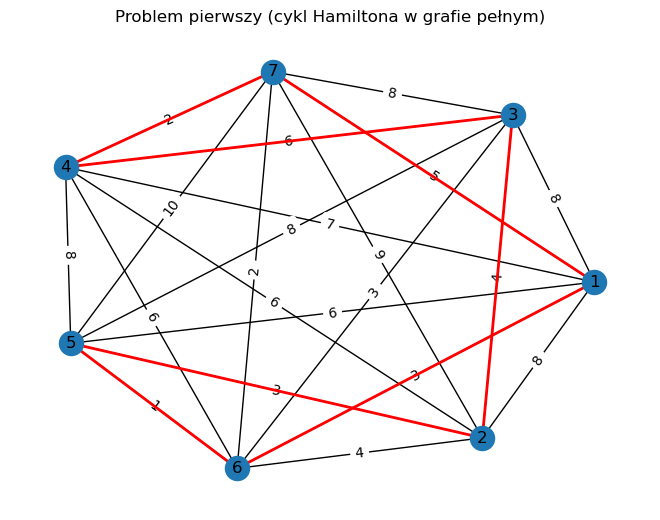

In [66]:
g1= generate_random_full_general(7)
path1, w1 = tsp_brute_force(g1)
print(f"Waga: {w1}, Trasa: {path1}")
g1.plot(path=path1,title="Problem pierwszy (cykl Hamiltona w grafie pełnym)")
plt.show()

Waga: 32, Trasa: [1, 5, 4, 3, 2, 6, 1]


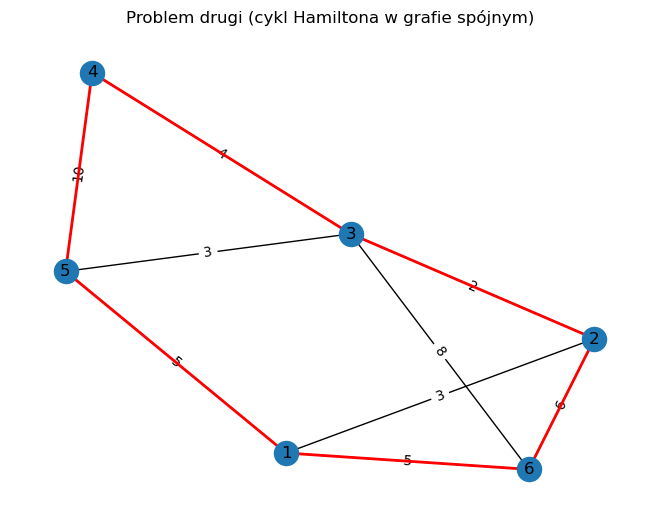

In [67]:
g2 = generate_random_sparse_weighted(6, 0.5)
path2, w2 = tsp_brute_force(g2)
print(f"Waga: {w2}, Trasa: {path2}")
g2.plot(path=path2,title="Problem drugi (cykl Hamiltona w grafie spójnym)")
plt.show()

Waga: 21, Trasa: [1, 3, 4, 3, 6, 2, 5, 1]


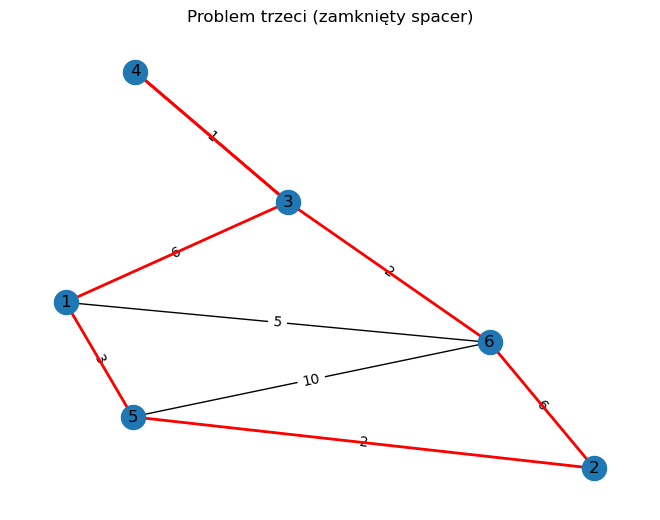

In [68]:
g3 = generate_random_connected_weighted(6)
path3, w3 = tsp_closed_walk(g3)
print(f"Waga: {w3}, Trasa: {path3}")
g3.plot(path=path3,title="Problem trzeci (zamknięty spacer)")
plt.show()

Przybliżona waga: 26, Trasa: [1, 8, 7, 2, 3, 4, 5, 6, 1]


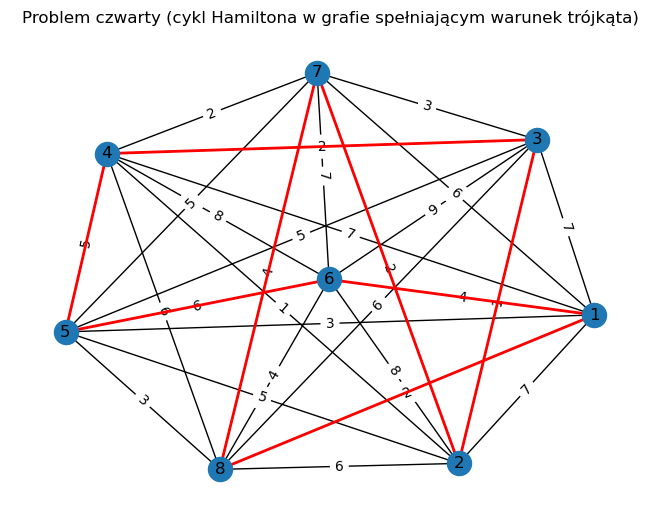

In [69]:
g4 = generate_random_full_metric(8)
path4, w4 = tsp_metric_mst_approx(g4)
print(f"Przybliżona waga: {w4}, Trasa: {path4}")
g4.plot(path=path4,title="Problem czwarty (cykl Hamiltona w grafie spełniającym warunek trójkąta)")
plt.show()

<h3>Porównanie czasu działania i wyniku algorytmów na tym samym grafie

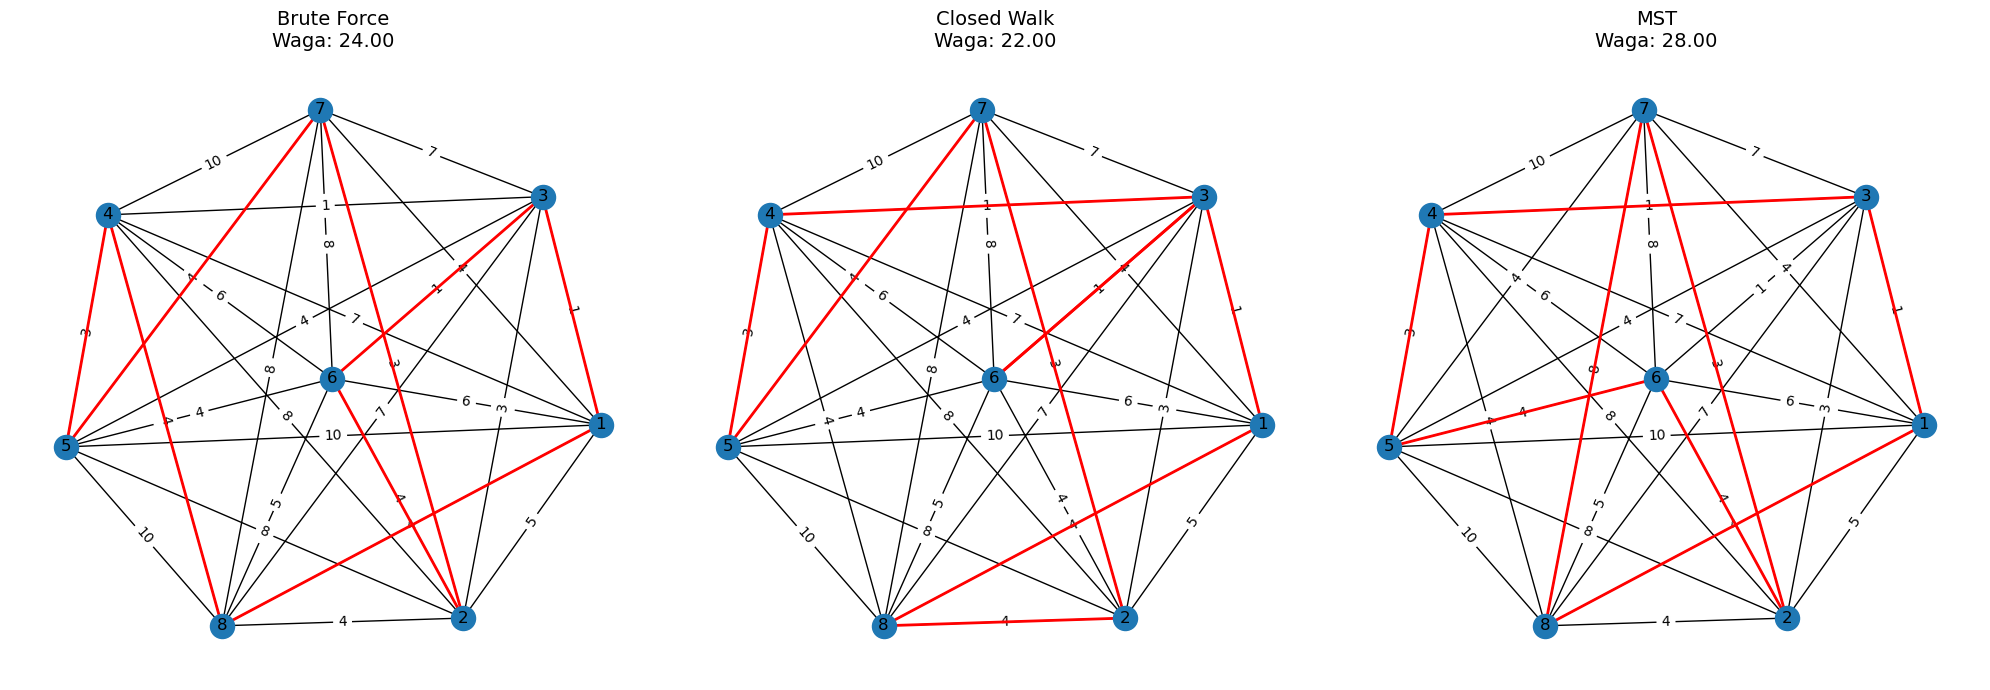

ALGORYTM                       | WAGA       | BŁĄD       | CZAS [s]     | SEKWENCJA WIERZCHOŁKÓW
Brute Force                    | 24.00      |   0.0%     | 12.3008 ms   | 1 -> 3 -> 6 -> 2 -> 7 -> 5 -> 4 -> 8 -> 1
Closed Walk                    | 22.00      |   0.0%     | 12.8256 ms   | 1 -> 3 -> 6 -> 3 -> 4 -> 5 -> 7 -> 2 -> 8 -> 1
MST                            | 28.00      |   16.7%    | 0.1723 ms    | 1 -> 3 -> 4 -> 5 -> 6 -> 2 -> 7 -> 8 -> 1


In [70]:

shared_graph = generate_random_full_general(8)

G_temp = nx.Graph()
for (u, v) in shared_graph.weights:
    G_temp.add_edge(u, v)
fixed_pos = nx.spring_layout(G_temp, seed=263328)


algorithms = [
    ("Brute Force", tsp_brute_force),
    ("Closed Walk", tsp_closed_walk),
    ("MST", tsp_metric_mst_approx)
]

results_data = []
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for i, (name, algorithm) in enumerate(algorithms):
    
    start_time = time.perf_counter()
    path, weight = algorithm(shared_graph)
    end_time = time.perf_counter()
    duration = end_time - start_time
    
    results_data.append({
        "name": name,
        "weight": weight,
        "path": path,
        "time": duration
    })
    current_ax = axes[i]
    shared_graph.plot(path=path, pos=fixed_pos, ax=current_ax)
    current_ax.set_title(f"{name}\nWaga: {weight:.2f}", fontsize=14)

plt.tight_layout()
plt.show()

print(f"{'ALGORYTM':<30} | {'WAGA':<10} | {'BŁĄD':<10} | {'CZAS [s]':<12} | {'SEKWENCJA WIERZCHOŁKÓW'}")


opt_w = results_data[0]['weight']

for res in results_data:
    name = res['name']
    weight = res['weight']
    path = res['path']
    duration = res['time']
    
    error = ((weight - opt_w) / opt_w) * 100
    error_str = f"{error:>6.1f}%" if error > 0 else "  0.0%"
    
    path_str = " -> ".join(map(str, path))
    time_str = f"{duration*1000:.4f} ms"

    
    print(f"{name:<30} | {weight:<10.2f} | {error_str:<10} | {time_str:<12} | {path_str}")

W tym przypadku algorytm spaceru zamkniętego okazał się najlepszy, osiągnął nawet niższą wagę niż podstawowy algorytm pełny. Ponieważ spacer dopuszcza przechodzenie kilka razy po tym samym wierzchołku, to wykorzystał on "skróty" o niższych wagach, co nie jest idealne jeżeli przyjmujemy oryginalny problem komiwojażera (nie możemy przejść wtedy po wierzchołku więcej niż raz).

Algorytm działający na drzewach rozpinających wyszedł gorzej niż pozostałe, ale jego czas wykonania jest 100-krotnie szybszy, różnica ta zwiększy się wraz ze wzrostem wierzchołków grafu (algorytm brute force ma złożoność O(n!)).